# Sección 5. Proyecciones de la red

Las proyecciones se calculan a partir de la red bipartita del inciso 4. Ambas conservan todos los nodos del conjunto proyectado, incluso los aislados.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display

import eda
import red

FIGURAS = REPO / "outputs" / "figuras"
TABLAS = REPO / "outputs" / "tablas"
FIGURAS.mkdir(parents=True, exist_ok=True)
TABLAS.mkdir(parents=True, exist_ok=True)

videos, comments = eda.cargar_procesados()
B = red.build_bipartita(comments)
A = red.proj_autores(B)
V = red.proj_videos(B)

nx.write_graphml(A, TABLAS / "proj_autores.graphml")
nx.write_graphml(V, TABLAS / "proj_videos.graphml")

## 5.1. Proyección autor-autor

Dos autores se conectan cuando comentaron al menos uno de los mismos videos. El peso cuenta los videos compartidos, no los comentarios escritos.

In [2]:
def resumen_proyeccion(nombre, graph):
    pesos = [d["weight"] for _, _, d in graph.edges(data=True)]
    componentes = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
    return {
        "red": nombre,
        "nodos": graph.number_of_nodes(),
        "aristas": graph.number_of_edges(),
        "aislados": nx.number_of_isolates(graph),
        "componentes": len(componentes),
        "componente_mayor": componentes[0],
        "peso_maximo": max(pesos, default=0),
        "aristas_peso_mayor_1": sum(p > 1 for p in pesos),
    }

resumen_autores = resumen_proyeccion("autor-autor", A)
display(pd.DataFrame([resumen_autores]))
display(Markdown(
    f"La proyección contiene **{resumen_autores['nodos']} autores** y "
    f"**{resumen_autores['aristas']} aristas**. La componente mayor reúne "
    f"**{resumen_autores['componente_mayor']} autores**. Hay "
    f"**{resumen_autores['aislados']} autores aislados**, cuentas que no comparten video "
    "con otro autor dentro de los comentarios recolectados."
))

,red,nodos,aristas,aislados,componentes,componente_mayor,peso_maximo,aristas_peso_mayor_1
0,autor-autor,332,10732,4,10,276,2,2


La proyección contiene **332 autores** y **10732 aristas**. La componente mayor reúne **276 autores**. Hay **4 autores aislados**, cuentas que no comparten video con otro autor dentro de los comentarios recolectados.

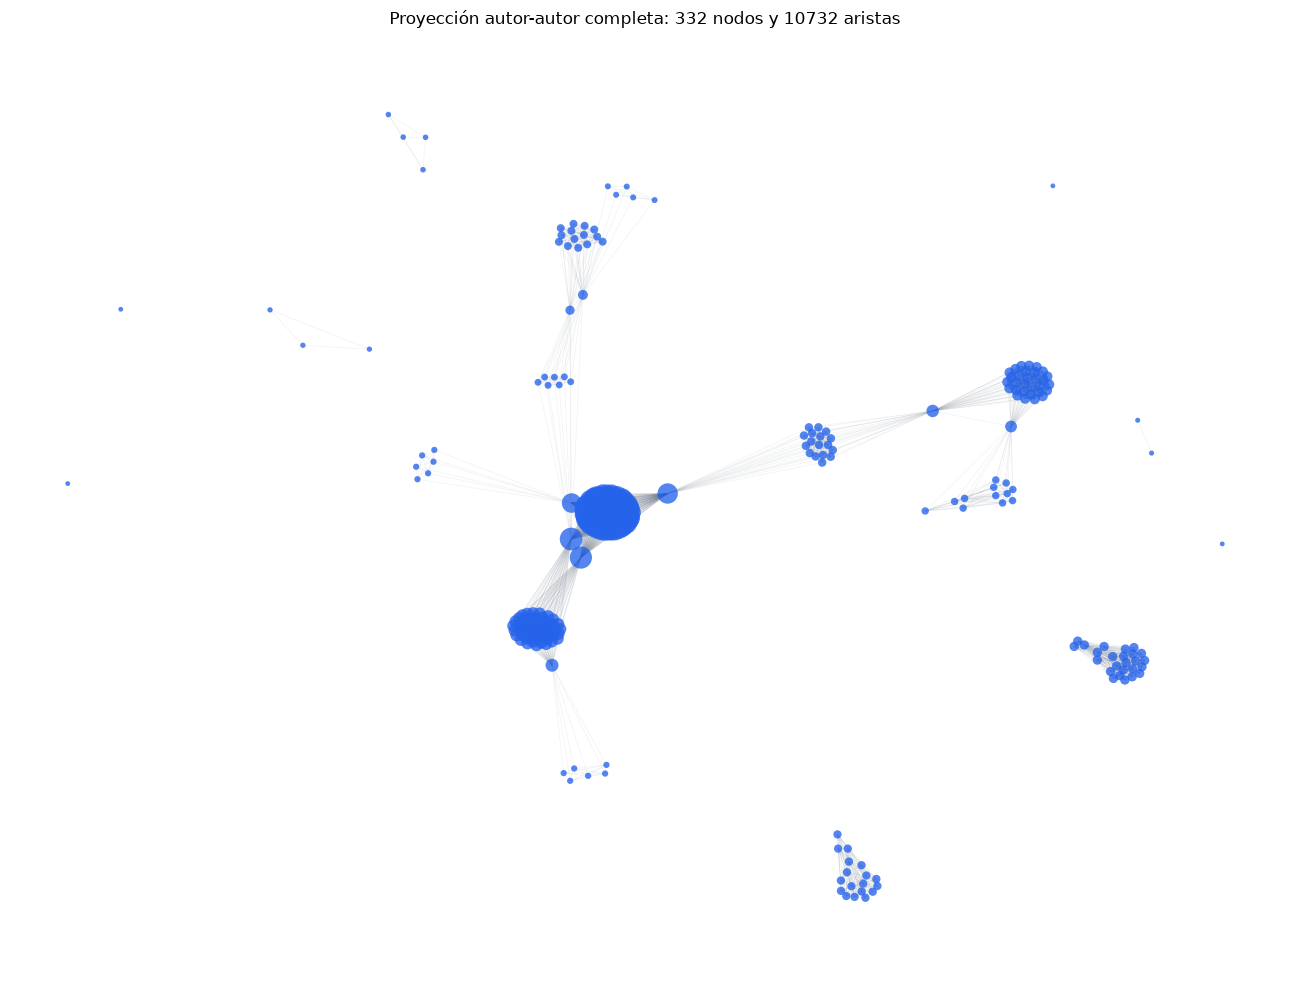

In [3]:
pos_a = nx.spring_layout(A, seed=42, weight="weight", k=0.22, iterations=80)
grados_a = dict(A.degree())

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_edges(
    A,
    pos_a,
    width=[0.15 + 0.35 * d["weight"] for _, _, d in A.edges(data=True)],
    alpha=0.08,
    edge_color="#475569",
    ax=ax,
)
nx.draw_networkx_nodes(
    A,
    pos_a,
    node_size=[12 + 1.4 * grados_a[n] for n in A],
    node_color="#2563eb",
    alpha=0.78,
    linewidths=0,
    ax=ax,
)
ax.set_title(
    f"Proyección autor-autor completa: {A.number_of_nodes()} nodos y "
    f"{A.number_of_edges()} aristas"
)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURAS / "05_proyeccion_autores.png", dpi=180, bbox_inches="tight")
plt.show()

## 5.2. Proyección video-video

Dos videos se conectan cuando comparten al menos un autor. El peso cuenta autores compartidos.

In [4]:
resumen_videos = resumen_proyeccion("video-video", V)
display(pd.DataFrame([resumen_videos]))

conteo_directo = eda.pares_videos_compartidos(comments, videos)
pesos_red = {
    frozenset((a, b)): d["weight"]
    for a, b, d in V.edges(data=True)
}
pesos_datos = {
    frozenset((fila.video_a, fila.video_b)): fila.autores_compartidos
    for fila in conteo_directo.itertuples()
}
assert pesos_red == pesos_datos
assert V.number_of_edges() == 11

display(Markdown(
    f"La proyección contiene **{resumen_videos['nodos']} videos** y "
    f"**{resumen_videos['aristas']} aristas**. Hay **{resumen_videos['aislados']} videos aislados**. "
    f"El peso máximo es **{resumen_videos['peso_maximo']} autores compartidos** y "
    f"**{resumen_videos['aristas_peso_mayor_1']} aristas** superan el peso uno."
))

,red,nodos,aristas,aislados,componentes,componente_mayor,peso_maximo,aristas_peso_mayor_1
0,video-video,19,11,9,10,10,2,2


La proyección contiene **19 videos** y **11 aristas**. Hay **9 videos aislados**. El peso máximo es **2 autores compartidos** y **2 aristas** superan el peso uno.

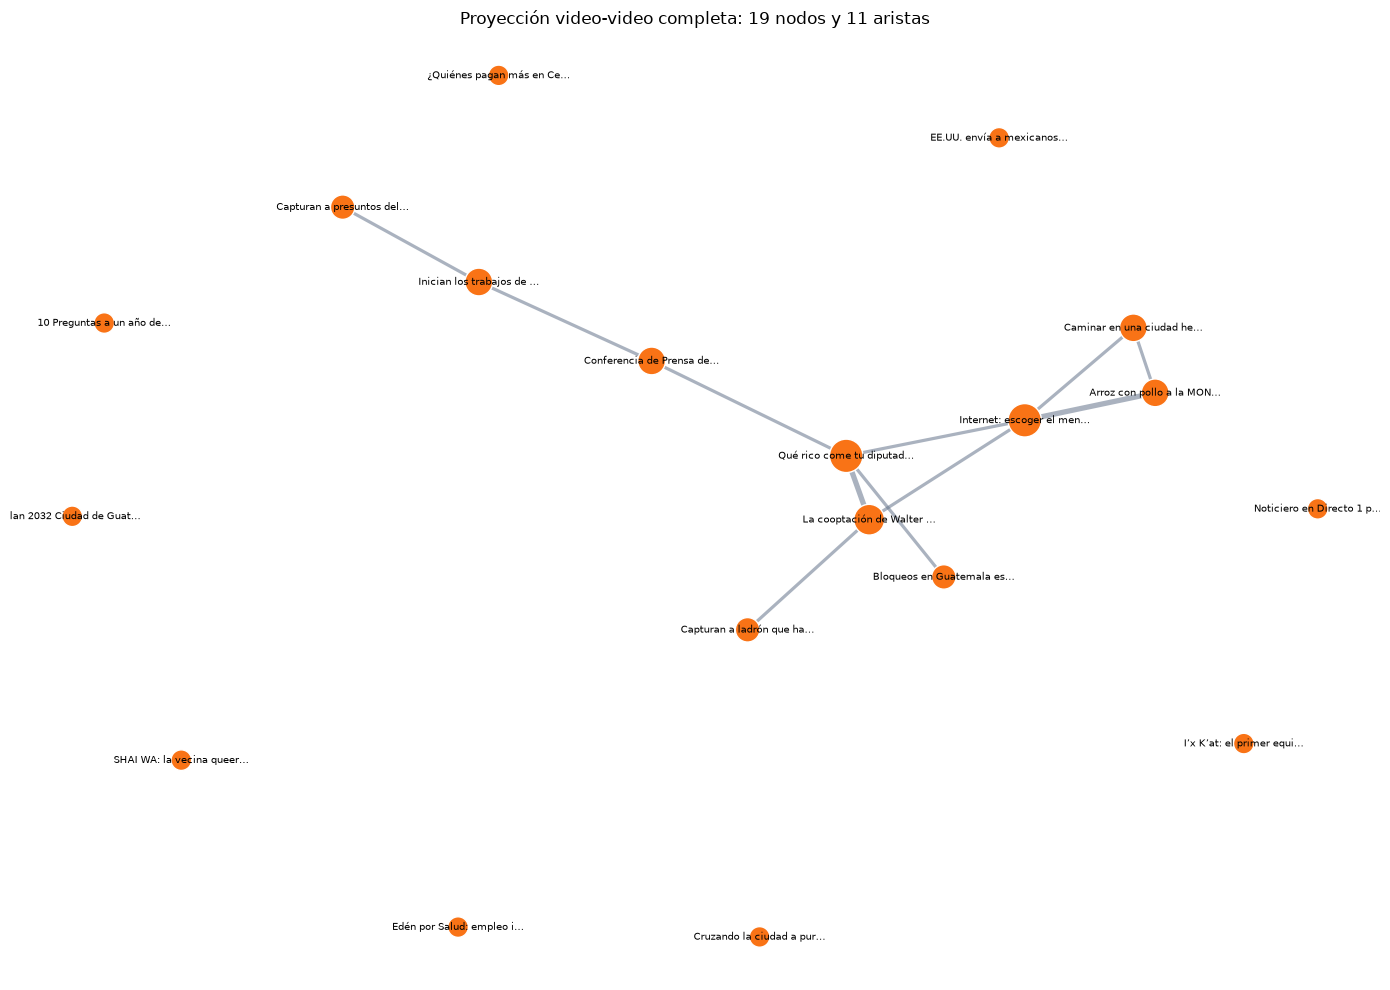

In [5]:
pos_v = nx.spring_layout(V, seed=42, weight="weight", k=1.1, iterations=120)
grados_v = dict(V.degree())
titulos = videos.set_index("video_id")["title"].to_dict()
labels = {n: titulos[n][:24] + ("…" if len(titulos[n]) > 24 else "") for n in V}

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(
    V,
    pos_v,
    width=[0.8 + 1.5 * d["weight"] for _, _, d in V.edges(data=True)],
    alpha=0.55,
    edge_color="#64748b",
    ax=ax,
)
nx.draw_networkx_nodes(
    V,
    pos_v,
    node_size=[220 + 90 * grados_v[n] for n in V],
    node_color="#f97316",
    edgecolors="white",
    linewidths=1,
    ax=ax,
)
nx.draw_networkx_labels(V, pos_v, labels=labels, font_size=7, ax=ax)
ax.set_title(
    f"Proyección video-video completa: {V.number_of_nodes()} nodos y "
    f"{V.number_of_edges()} aristas"
)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURAS / "05_proyeccion_videos.png", dpi=180, bbox_inches="tight")
plt.show()

## 5.3. Comparación de las proyecciones

In [6]:
comparacion = pd.DataFrame([resumen_autores, resumen_videos])
display(comparacion)
display(Markdown(
    f"La proyección autor-autor tiene **{A.number_of_edges()} aristas** porque cada video "
    "con varios comentaristas genera conexiones entre todos esos autores. La proyección "
    f"video-video solo tiene **{V.number_of_edges()} aristas**: en esta muestra, pocos autores "
    "comentaron en más de un video. Por ello, una red densa de autores dentro de un video no "
    "implica que las audiencias de distintos videos estén ampliamente conectadas."
))

,red,nodos,aristas,aislados,componentes,componente_mayor,peso_maximo,aristas_peso_mayor_1
0,autor-autor,332,10732,4,10,276,2,2
1,video-video,19,11,9,10,10,2,2


La proyección autor-autor tiene **10732 aristas** porque cada video con varios comentaristas genera conexiones entre todos esos autores. La proyección video-video solo tiene **11 aristas**: en esta muestra, pocos autores comentaron en más de un video. Por ello, una red densa de autores dentro de un video no implica que las audiencias de distintos videos estén ampliamente conectadas.

La proyección autor-autor representa co-participación en contenido. La proyección video-video representa solapamiento observado entre audiencias. Ninguna proyección demuestra amistad, conversación o aprobación entre cuentas.